# **Assignment 1:** Predicting Maternal Health Risk Using Classical Machine Learning and a Neural Network from Scratch

**Student Name:** Adossi Fred William

**Course:** Introduction to Machine Learning

**Date:** May 2026

---

## **Overview**

## Abstract

In this notebook,  I have used different machine learning models to predict maternal health risk levels by using medical data that are collected from pregnant women. The project basically compares two classical machine learning models: Logistic Regression and Random Forest together with a three-layer neural network and it was built entirely from scratch by using NumPy. The dataset that I have used for this study is titled "Maternal Health Risk" and it comes from the UCI Machine Learning Repository.

Before starting to build any models, I have first of all  explored the data carefully to understand what it contains, how each feature is spread out, how variables relate to each other and how well the risk categories are separated.  From there, I used what I found to decide on how to clean the data and which models to try instead of just guessing.

I tested three different the configurations for both Logistic Regression and Random Forest to see how changing the hyperparameters affects the results. Then I have checked how well each model performed by using accuracy, precision, recall, F1-score, confusion matrices, and ROC-AUC curves. After that, I have built a neural network, where I had to code everything myself forward propagation, loss calculation, and backpropagation.

Finally, I ran many neural network experiments by using different architectures and learning rates and then compared all the results together to see which approach worked best for predicting maternal health risks. The overall goal of this project is to explore how machine learning can help detect maternal health risks early using simple medical measurements.

  


---

## Table of Contents

1. Dataset Selection and Justification
2. Imports and Setup
3. Data Loading
4. Exploratory Data Analysis
5. Preprocessing
6. Classical Machine Learning Models
7. Neural Network from Scratch
8. Comparative Analysis and Discussion
9. References

---
# 1. Dataset Selection and Justification

The dataset that I selected for this assignment is the Maternal Health Risk dataset from the UCI Machine Learning Repository. That data was collected from hospitals, community clinics, and maternal healthcare centers in rural Bangladesh by using an IoT-based health monitoring system. It contains 1,013 records and six medical features such as age, systolic blood pressure, diastolic blood pressure, blood glucose, body temperature, and heart rate. The target variable is maternal risk level, which is divided into three categories such as low risk, mid risk and high risk.

I have selected this dataset because maternal health has always been firsly a serious problem in many countries, mainly in Africa where many women still face a lot of complications during pregnancy and childbirth. In many regions, some complications are detected only at the last moment and most of time when it is already too late. According to the World Health Organization (2024), around 800 women die every day from preventable causes related to pregnancy and childbirth.

I have personally seen and heard many cases for example in Chad, more precisely in the city of Moundou, a woman remained in labor for nearly twenty hours before giving birth the following morning. After giving birth, everything seemed normal and she returned home with her baby. However, short time after going home, she developed a serious medical complications and almost lost her life. It was only after returning to the hospital that doctors discovered the problem and managed to treat her in time. In another similar case, my uncle's wife unfortunately did not survive under the complications related to childbirth.

Because of these, I think that building a Machine Learning system that can analyze medical measurements and predict maternal risk levels early would be very useful and save a lot lives.

Secondly, the dataset allows both classical machine learning algorithms and neural networks to be evaluated by using the same data. As the project compares Logistic Regression, Random Forest, and a neural network built from scratch, this dataset provides a good opportunity to study how different models perform on the same classification task.

Another reason that made me select this dataset is that it does not contain missing values, which simplifies preprocessing stage and allows more focus on analysis, training, and comparison of the Machine Learning models.

Finally, the dataset is not a default scikit-learn dataset, which meets the assignment requirement.

# 2. Imports and Setup

In this section, I imported all the libraries needed for data analysis, visualization, preprocessing, and machine learning tasks throughout the project. I mainly used NumPy and Pandas for data handling and numerical operations while Matplotlib and Seaborn helped me create visualizations and perform exploratory data analysis. I also used Scikit-learn for preprocessing the data, training the machine learning models, and evaluating their performance.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

!pip install ucimlrepo -q
from ucimlrepo import fetch_ucirepo

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, auc
)

SEED = 42
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = ['#4C9BE8', '#E8694C', '#4CE87A', '#E8C34C', '#9B4CE8']

print('All imports successful.')

All imports successful.


# 3. Data Loading

I directly imported the dataset from the UCI Machine Learning Repository using the ucimlrepo package. After loading the data, I separated the input features and the target variable in order to prepare for preprocessing and model training.

In [ ]:
dataset = fetch_ucirepo(id=863)
X_raw = dataset.data.features
y_raw = dataset.data.targets

print('Feature matrix shape:', X_raw.shape)
print('Target shape:', y_raw.shape)
print()
print('Feature columns:', list(X_raw.columns))
print()
print('Class distribution:')
print(y_raw.iloc[:, 0].value_counts())
print()
print('Missing values per feature:')
print(X_raw.isnull().sum())
print()
print('First five rows:')
print(X_raw.head())

Feature matrix shape: (1014, 6)
Target shape: (1014, 1)

Feature columns: ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

Class distribution:
RiskLevel
low risk     406
mid risk     336
high risk    272
Name: count, dtype: int64

Missing values per feature:
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
dtype: int64

First five rows:
   Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate
0   25         130           80  15.0      98.0         86
1   35         140           90  13.0      98.0         70
2   29          90           70   8.0     100.0         80
3   30         140           85   7.0      98.0         70
4   35         120           60   6.1      98.0         76


# 4. Exploratory Data Analysis

Before building the machine learning models, I first of all needed to clearly understand the dataset, and this is where Exploratory Data Analysis became a really important part of my process because it helped me see the patterns, relationships, and possible problems in the data that could affect my models later on. To do this, I focused on four main things:

*   Understanding how the features are distributed across the dataset
*   Checking the relationships between the features and the different risk levels

*   Identifying which features stood out as the most useful predictors
*   Getting a clear picture of which features would actually help the models make good predictions

I did all of this before jumping into preprocessing and model selection because I did not want to just guess or assume things about the data, I rather wanted every decision that I made to be based on what the data was actually showing me.

## 4.1 Univariate Analysis

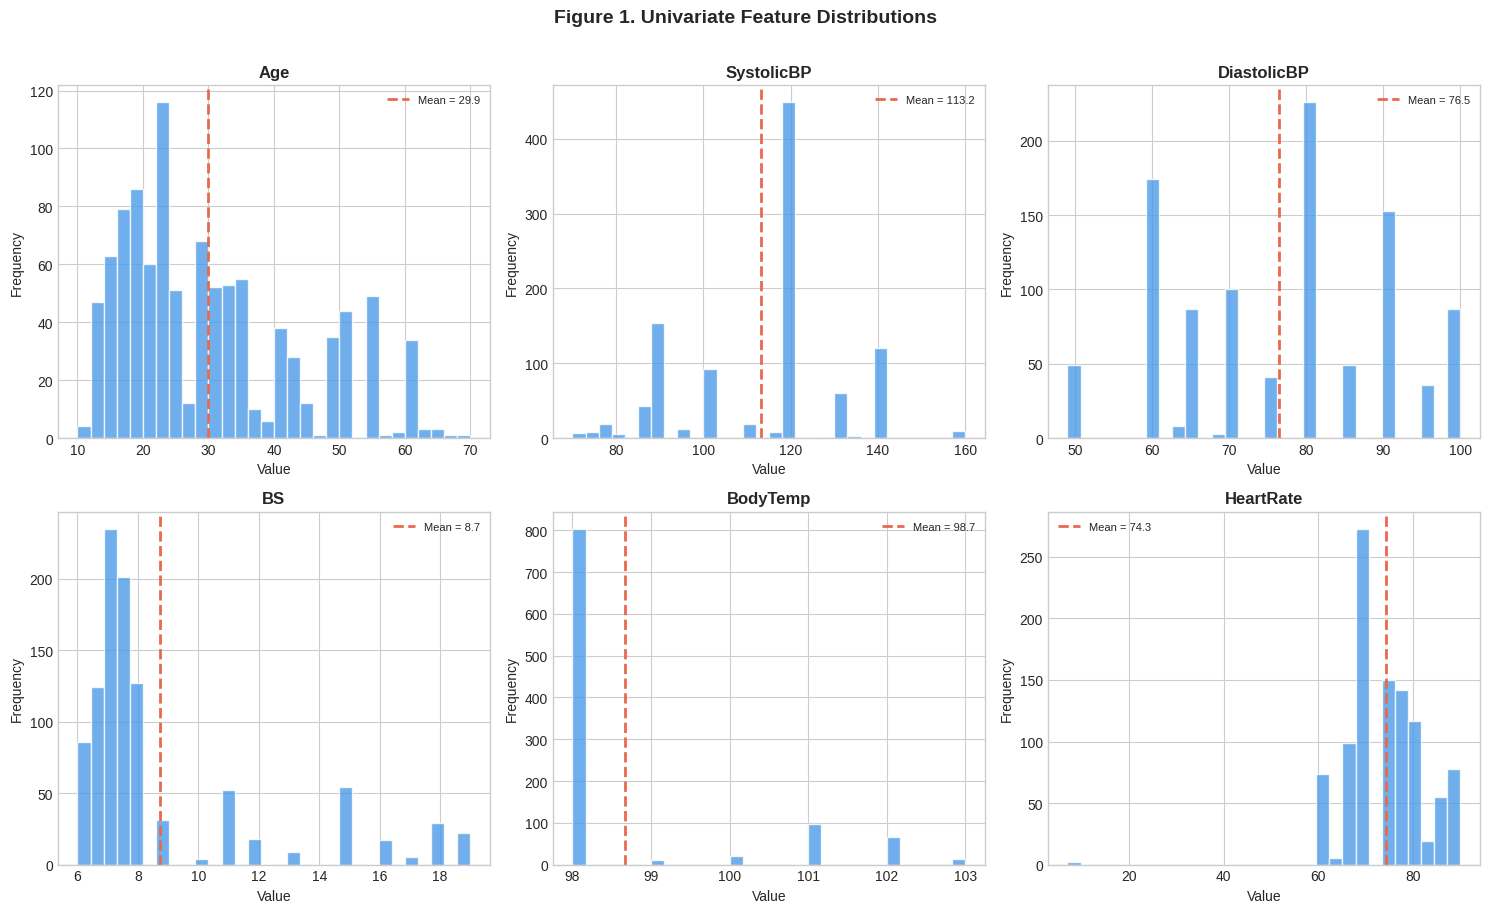

Descriptive statistics:
            Age  SystolicBP  DiastolicBP        BS  BodyTemp  HeartRate
count  1014.000    1014.000     1014.000  1014.000  1014.000   1014.000
mean     29.872     113.198       76.461     8.726    98.665     74.302
std      13.474      18.404       13.886     3.294     1.371      8.089
min      10.000      70.000       49.000     6.000    98.000      7.000
25%      19.000     100.000       65.000     6.900    98.000     70.000
50%      26.000     120.000       80.000     7.500    98.000     76.000
75%      39.000     120.000       90.000     8.000    98.000     80.000
max      70.000     160.000      100.000    19.000   103.000     90.000


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(X_raw.columns):
    axes[i].hist(X_raw[col], bins=30, color=COLORS[0], alpha=0.8, edgecolor='white')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    mean_val = X_raw[col].mean()
    axes[i].axvline(mean_val, color=COLORS[1], linestyle='--', lw=2,
                    label=f'Mean = {mean_val:.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Figure 1. Univariate Feature Distributions',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Descriptive statistics:')
print(X_raw.describe().round(3))

**Interpretation of Figure 1.**

Looking at the distributions, blood glucose stood out the most to me because most patients had lower values but a few had very high readings, which could probally be linked to diabetes-related conditions during pregnancy. Blood pressure looked more balanced and spread out across patients, while body temperature was almost the same for everyone, which made me wonder how useful it would be for prediction. Age covered a considerable range, showing that the dataset includes both younger and older patients, and heart rate also varied in a moderate way, and together these observations gave me a good idea of which features might be more helpful than others when building the models.

## 4.2 Bivariate Analysis: Feature-Class Relationships

In this section, I looked at how each feature behaves across the three different risk levels, because features that show clear differences between the classes are the ones that are most convenient to help the models make better predictions while features that look very similar across all three classes may need more complex models to get useful information out of them.

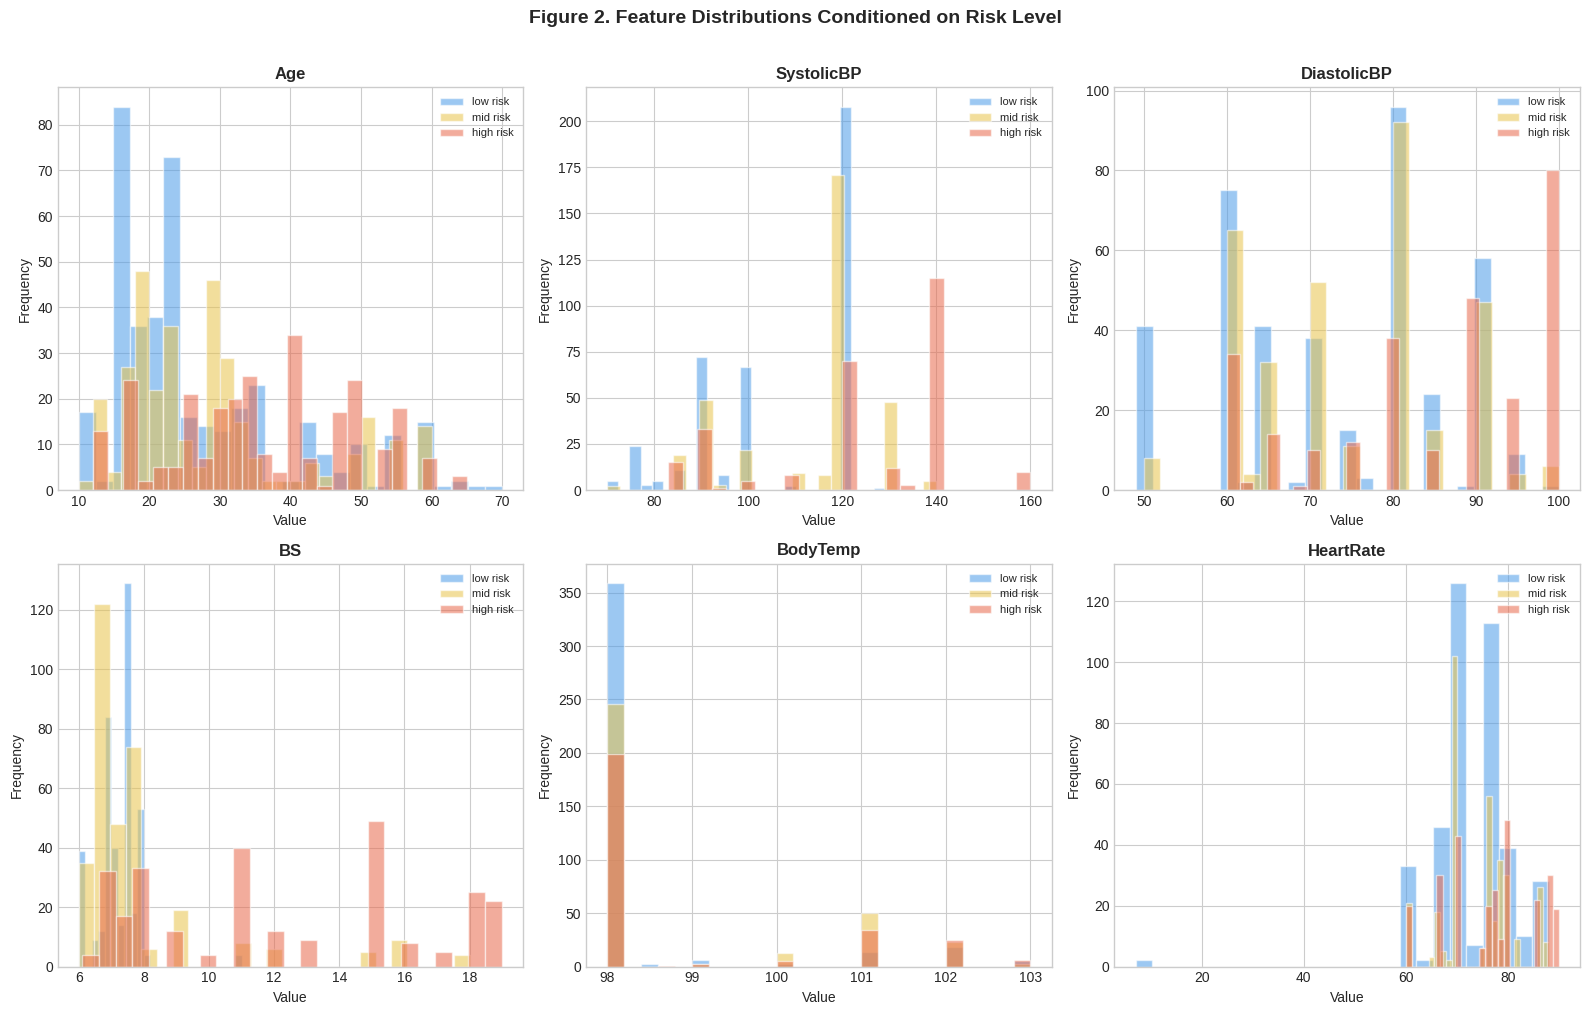

In [ ]:
df_eda = X_raw.copy()
df_eda['RiskLevel'] = y_raw.iloc[:, 0].values
color_map = {'low risk': COLORS[0], 'mid risk': COLORS[3], 'high risk': COLORS[1]}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(X_raw.columns):
    for label in ['low risk', 'mid risk', 'high risk']:
        subset = df_eda[df_eda['RiskLevel'] == label][col]
        axes[i].hist(subset, bins=25, alpha=0.55,
                     color=color_map[label], label=label, edgecolor='white')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.suptitle('Figure 2. Feature Distributions Conditioned on Risk Level',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

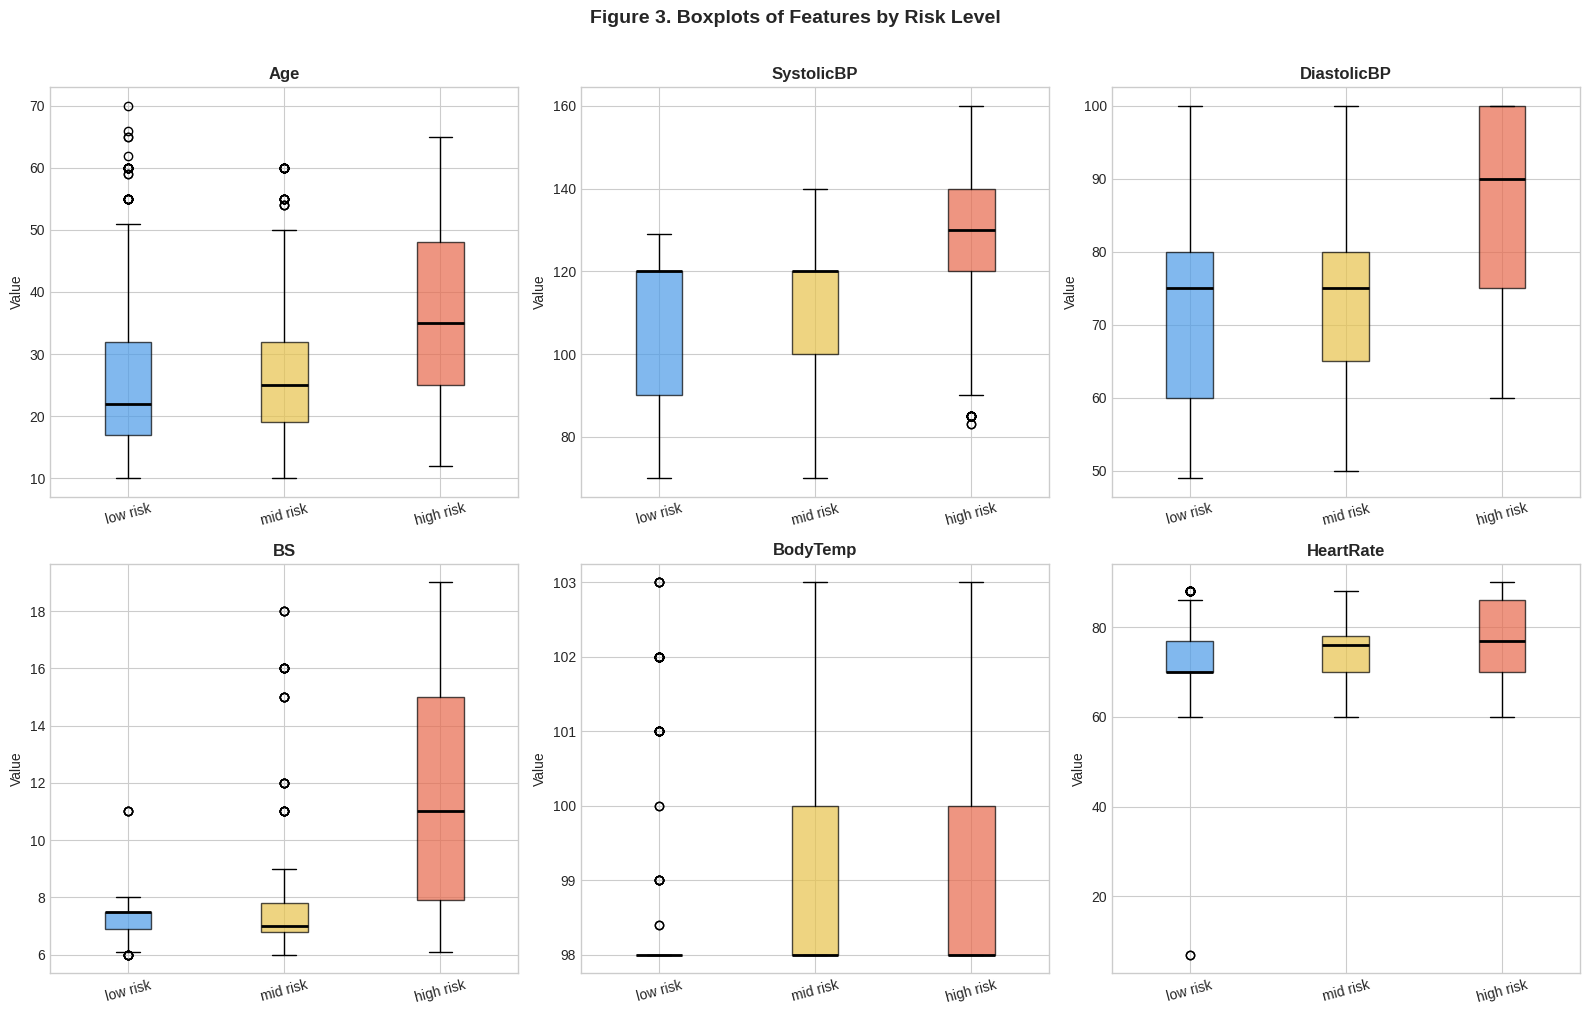

Mean value of each feature by risk level:
              Age  SystolicBP  DiastolicBP      BS  BodyTemp  HeartRate
RiskLevel                                                              
high risk  36.217     124.195       85.074  12.123    98.899     76.743
low risk   26.869     105.867       72.534   7.220    98.369     72.771
mid risk   28.363     113.155       74.232   7.796    98.833     74.176

Standard deviation of each feature by risk level:
              Age  SystolicBP  DiastolicBP     BS  BodyTemp  HeartRate
RiskLevel                                                             
high risk  13.032      20.227       14.112  4.174     1.559      8.698
low risk   13.122      15.894       13.054  0.646     1.109      8.293
mid risk   12.553      14.983       11.490  2.286     1.434      6.767


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(X_raw.columns):
    data_by_class = [
        df_eda[df_eda['RiskLevel'] == label][col].values
        for label in ['low risk', 'mid risk', 'high risk']
    ]
    bp = axes[i].boxplot(data_by_class, patch_artist=True,
                         labels=['low risk', 'mid risk', 'high risk'],
                         medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], [COLORS[0], COLORS[3], COLORS[1]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('Figure 3. Boxplots of Features by Risk Level',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Mean value of each feature by risk level:')
print(df_eda.groupby('RiskLevel')[list(X_raw.columns)].mean().round(3))
print()
print('Standard deviation of each feature by risk level:')
print(df_eda.groupby('RiskLevel')[list(X_raw.columns)].std().round(3))

**Interpretation of Figures 2 and 3.**

The analysis showed that blood glucose was the most useful feature for predicting maternal risk, since patients in the high-risk group had much higher glucose levels compared to the others, which made it stand out straight away. Systolic blood pressure was also really useful, as high-risk patients tended to have higher readings, and diastolic blood pressure showed a similar pattern but was a bit less clear. Age had some connection to risk level too, since older patients showed up more in the high-risk group, but there was still a lot of overlap between the classes. Heart rate and body temperature did not really show much difference across the three risk levels, so I felt like these two features would not help much with the predictions. Overall, blood glucose and blood pressure were clearly the most important features out of all six.

## 4.3 Inter-Feature Correlation Analysis

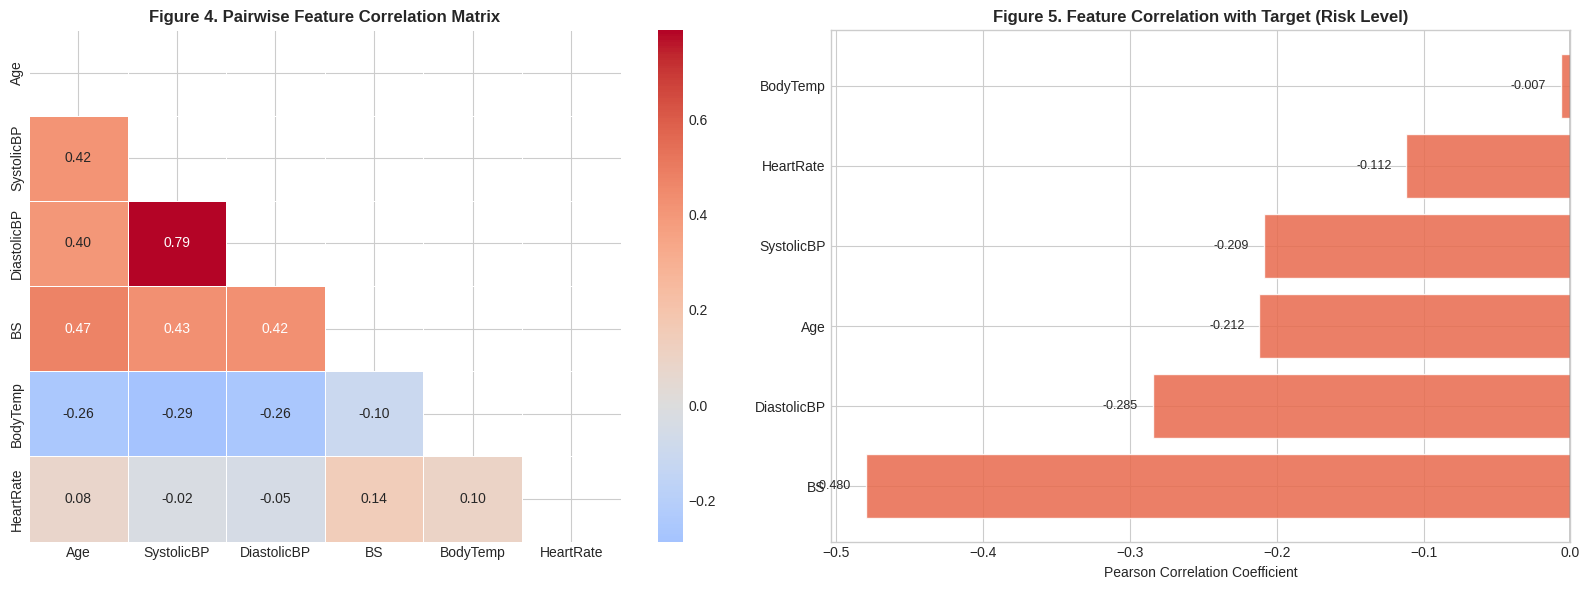

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr = X_raw.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0], linewidths=0.5, annot_kws={'size': 10})
axes[0].set_title('Figure 4. Pairwise Feature Correlation Matrix',
                  fontsize=12, fontweight='bold')

le_temp = LabelEncoder()
y_enc_temp = le_temp.fit_transform(y_raw.iloc[:, 0].values)
df_corr = X_raw.copy()
df_corr['RiskLevel_encoded'] = y_enc_temp
target_corr = df_corr.corr()['RiskLevel_encoded'].drop('RiskLevel_encoded').sort_values()

colors_bar = [COLORS[1] if v < 0 else COLORS[0] for v in target_corr.values]
axes[1].barh(target_corr.index, target_corr.values,
             color=colors_bar, alpha=0.85, edgecolor='white')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_title('Figure 5. Feature Correlation with Target (Risk Level)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Pearson Correlation Coefficient')
for i, val in enumerate(target_corr.values):
    axes[1].text(val + 0.01 if val >= 0 else val - 0.01,
                 i, f'{val:.3f}', va='center',
                 ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

**Interpretation of Figures 4 and 5.**

Looking at the correlation results, I noticed that systolic and diastolic blood pressure had a moderate positive correlation of around 0.79, which was not really surprising since the two are naturally linked. Even though this correlation exists, I decided to keep both features because it was not strong enough to cause any real problems for the models. The correlation matrix also confirmed what I already noticed in the bivariate analysis, where blood glucose had the strongest relationship with risk level followed by systolic and diastolic blood pressure, and then age, while heart rate and body temperature had the weakest relationships overall.

## 4.4 Feature Selection Justification

After looking at all the results from the analysis, I decided to keep all six features. Even the weakest ones like body temperature and heart rate might still be useful because they could work together with the stronger features in ways that are not easy to see just by looking at the graphs. I also felt like removing features without any real proof that it would make things better was not the right thing to do, so I just kept all of them and let the models figure out what is actually useful. I will also come back to this decision later in Section 6 when I look at feature importance to see if keeping all six features was the right call.

# 5. Preprocessing

## 5.1 Target Encoding

The target variable contains three categorical labels, which are low risk, mid risk, and high risk, and machine learning models cannot work directly with text labels because they require numerical inputs for all calculations during training. For this reason, I used LabelEncoder from scikit-learn to convert these three text labels into numerical values of 0, 1, and 2, which allowed the models to process the target variable correctly during training and evaluation.

## 5.2 Train, Validation, and Test Split

I split the dataset into three parts: 70% for training, 15% for validation, and 15% for testing. I used stratified sampling to make sure that the proportion of each risk class stayed the same across all three splits, because without stratification, one split could end up with very few samples from one class, which would make training and evaluation unfair and unreliable. The test set was kept completely separate and untouched throughout the entire training process, so that the final evaluation reflects how well the models would perform on data they have never seen before, which gives a fair and unbiased measure of performance. The validation set was used specifically during neural network training to monitor how well the model was generalising after each epoch, which helped me detect overfitting early.

## 5.3 Feature Scaling

I used StandardScaler to bring all the features to the same scale by subtracting the mean and dividing by the standard deviation of each feature, so that every feature ends up with a mean of zero and a standard deviation of one. This step was especially important for logistic regression because it uses gradient descent to optimise its parameters, and when features are on very different scales, the gradient steps become uneven and the model takes much longer to converge or may not converge properly at all. I made sure to fit the scaler only on the training set and then apply it to the validation and test sets without refitting, because if I had fit it on all the data together, the scaler would have used information from the validation and test sets to calculate the mean and standard deviation, which would be a form of data leakage and would give unfairly optimistic results.


In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw.iloc[:, 0].values)

print('Class encoding:')
for i, cls in enumerate(le.classes_):
    count = (y_encoded == i).sum()
    print(f'  {cls} -> {i},  n = {count}')

X_arr = X_raw.values

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_arr, y_encoded, test_size=0.15, random_state=SEED, stratify=y_encoded)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.176,
    random_state=SEED, stratify=y_trainval)

print(f'\nTrain: {len(X_train)} | Validation: {len(X_val)} | Test: {len(X_test)}')

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print(f'\nScaling complete.')
print(f'Train mean (feature 0): {X_train_sc[:, 0].mean():.6f}  (expected ~0)')
print(f'Train std  (feature 0): {X_train_sc[:, 0].std():.6f}   (expected ~1)')

NUM_CLASSES   = 3
y_test_bin    = label_binarize(y_test, classes=[0, 1, 2])
feature_names = list(X_raw.columns)

Class encoding:
  high risk -> 0,  n = 272
  low risk -> 1,  n = 406
  mid risk -> 2,  n = 336

Train: 709 | Validation: 152 | Test: 153

Scaling complete.
Train mean (feature 0): 0.000000  (expected ~0)
Train std  (feature 0): 1.000000   (expected ~1)


# 6. Classical Machine Learning Models

## Model Selection Rationale

For the classical machine learning part, I chose two models: Logistic Regression and Random Forest. I picked Logistic Regression first because it is a simple model and the analysis already showed that some features like blood glucose and blood pressure had a clear relationship with risk level, so I thought a simple model could already do a great job. I also chose Random Forest because the analysis showed that some classes overlapped quite a bit, which meant a simple model like Logistic Regression might not be enough on its own, and Random Forest is better at handling more complicated patterns in the data. To compare both models fairly, I used accuracy, precision, recall, F1-score, confusion matrices, and ROC-AUC curves, and I tested three different settings for each model based on what I found during the analysis.

In [ ]:
def evaluate(model, X_tr, y_tr, X_te, y_te, label=''):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    result = {
        'label':     label,
        'accuracy':  accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred, average='macro', zero_division=0),
        'recall':    recall_score(y_te, y_pred, average='macro', zero_division=0),
        'f1':        f1_score(y_te, y_pred, average='macro', zero_division=0),
        'cm':        confusion_matrix(y_te, y_pred),
        'model':     model,
        'preds':     y_pred
    }
    if hasattr(model, 'predict_proba'):
        result['proba'] = model.predict_proba(X_te)
    return result

results_classical = []
print('Evaluation helper defined.')

Evaluation helper defined.


## 6.1 Logistic Regression

For Logistic Regression, I tested three different settings using the C value, which controls how much the model is allowed to rely on each feature. With C equal to 0.1, the model is kept more strict and cannot put too much weight on any feature, which I thought made sense because some features like body temperature and heart rate were not very useful anyway. With C equal to 1.0, I just used the default setting which gives a nice balance between the two extremes. With C equal to 5.0, the model has more freedom to rely on the features it finds useful, which I thought could help since features like blood glucose and blood pressure were clearly important and I did not want the model to ignore them.

In [ ]:
lr_runs = [
    ('LR  C=0.1', {'C': 0.1,  'max_iter': 2000, 'random_state': SEED,
                   'solver': 'lbfgs', 'multi_class': 'auto'}),
    ('LR  C=1.0', {'C': 1.0,  'max_iter': 2000, 'random_state': SEED,
                   'solver': 'lbfgs', 'multi_class': 'auto'}),
    ('LR  C=5.0', {'C': 5.0,  'max_iter': 2000, 'random_state': SEED,
                   'solver': 'lbfgs', 'multi_class': 'auto'}),
]

for label, cfg in lr_runs:
    res = evaluate(LogisticRegression(**cfg),
                   X_train_sc, y_train, X_test_sc, y_test, label=label)
    results_classical.append(res)
    print(f'{label} | Acc={res["accuracy"]:.4f} | '
          f'P={res["precision"]:.4f} | R={res["recall"]:.4f} | '
          f'F1={res["f1"]:.4f}')

LR  C=0.1 | Acc=0.6340 | P=0.6452 | R=0.6309 | F1=0.6193
LR  C=1.0 | Acc=0.6144 | P=0.6116 | R=0.6145 | F1=0.6007
LR  C=5.0 | Acc=0.6144 | P=0.6085 | R=0.6145 | F1=0.6007


## 6.2 Random Forest

For Random Forest, I also tested three different settings by changing the number of trees and how deep each tree was allowed to grow. In the first setting, I used 100 trees with a maximum depth of 5, which keeps the trees quite shallow, and I wanted to see if simple rules based on the most important features would already be enough to get good results. In the second setting, I used 200 trees with a maximum depth of 10, which gives the model more room to pick up on more complex patterns between features, and I thought this could be especially helpful for the mid-risk class since it overlapped a lot with the other classes. In the third setting, I used 200 trees with no limit on depth, which basically gives the model full freedom to learn as much as it can from the data. For all three settings, I also made sure to set the class weight to balanced so that the model would treat all three classes fairly and not just focus on the most common one.

In [ ]:
rf_runs = [
    ('RF  n=100 d=5',    {'n_estimators': 100, 'max_depth': 5,
                          'random_state': SEED, 'class_weight': 'balanced'}),
    ('RF  n=200 d=10',   {'n_estimators': 200, 'max_depth': 10,
                          'random_state': SEED, 'class_weight': 'balanced'}),
    ('RF  n=200 d=None', {'n_estimators': 200, 'max_depth': None,
                          'random_state': SEED, 'class_weight': 'balanced'}),
]

for label, cfg in rf_runs:
    res = evaluate(RandomForestClassifier(**cfg),
                   X_train_sc, y_train, X_test_sc, y_test, label=label)
    results_classical.append(res)
    print(f'{label} | Acc={res["accuracy"]:.4f} | '
          f'P={res["precision"]:.4f} | R={res["recall"]:.4f} | '
          f'F1={res["f1"]:.4f}')

RF  n=100 d=5 | Acc=0.7059 | P=0.7357 | R=0.7044 | F1=0.7073
RF  n=200 d=10 | Acc=0.8235 | P=0.8356 | R=0.8263 | F1=0.8304
RF  n=200 d=None | Acc=0.8366 | P=0.8484 | R=0.8431 | F1=0.8444


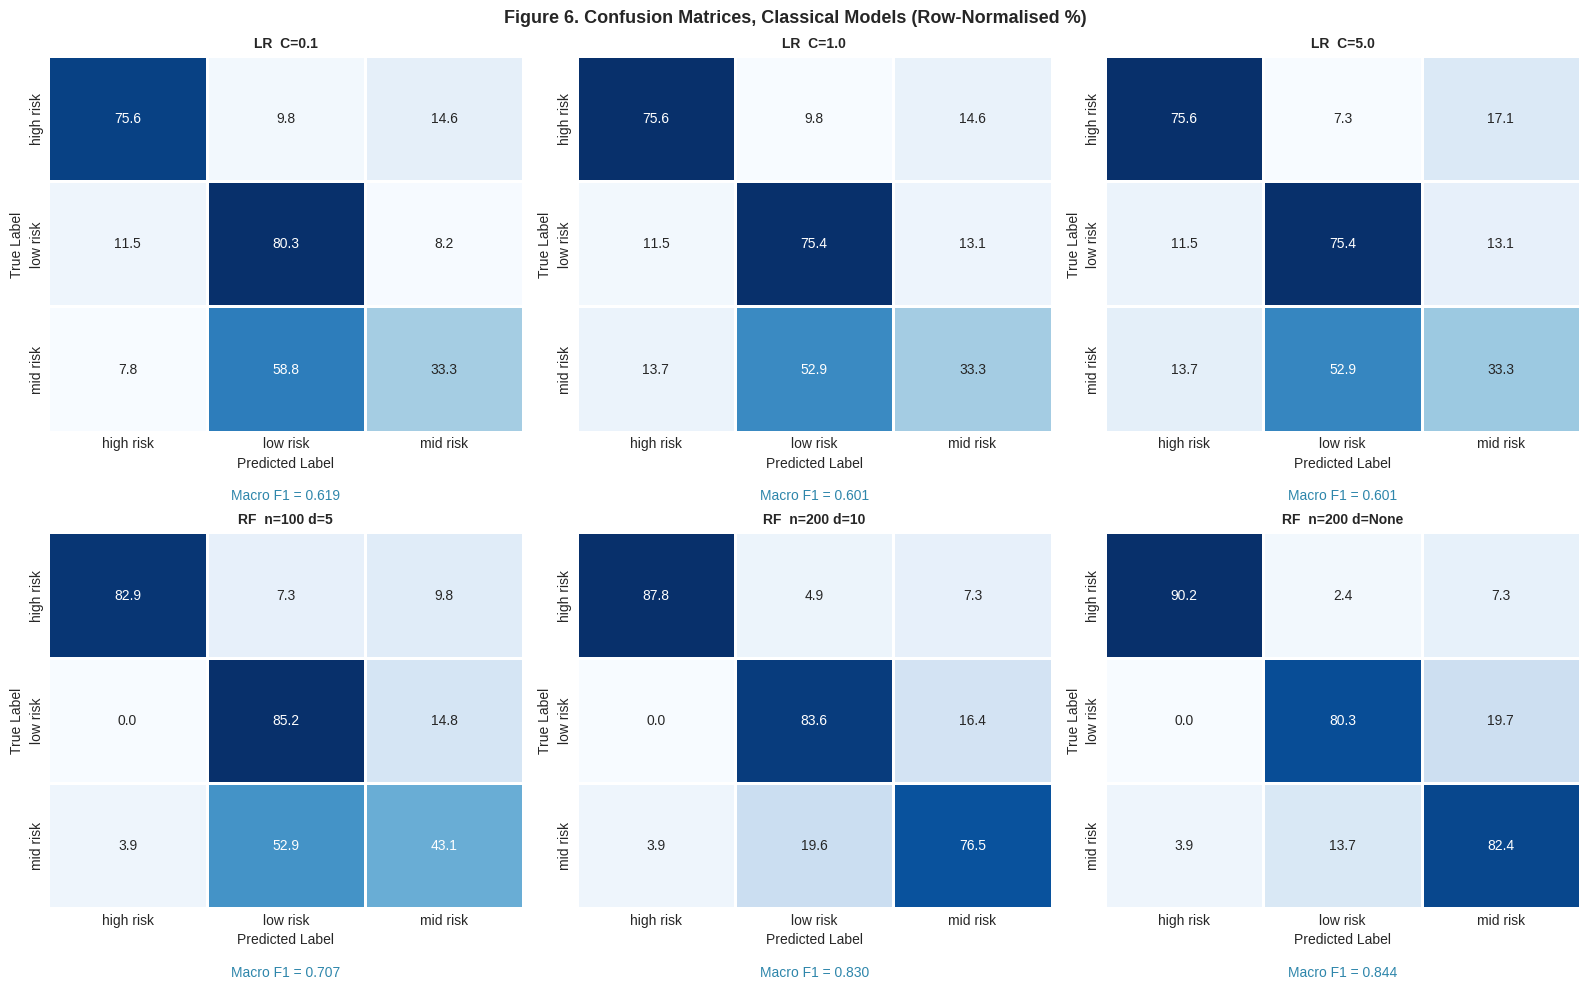

In [ ]:
# Confusion matrices, all 6 classical experiments
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, res in enumerate(results_classical):
    cm_pct = (res['cm'].astype(float) /
               res['cm'].sum(axis=1, keepdims=True) * 100)
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=axes[i],
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=1, cbar=False)
    axes[i].set_title(res['label'], fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')
    axes[i].text(0.5, -0.18, f'Macro F1 = {res["f1"]:.3f}',
                 ha='center', transform=axes[i].transAxes,
                 fontsize=10, color='#2E86AB')

plt.suptitle('Figure 6. Confusion Matrices, Classical Models (Row-Normalised %)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

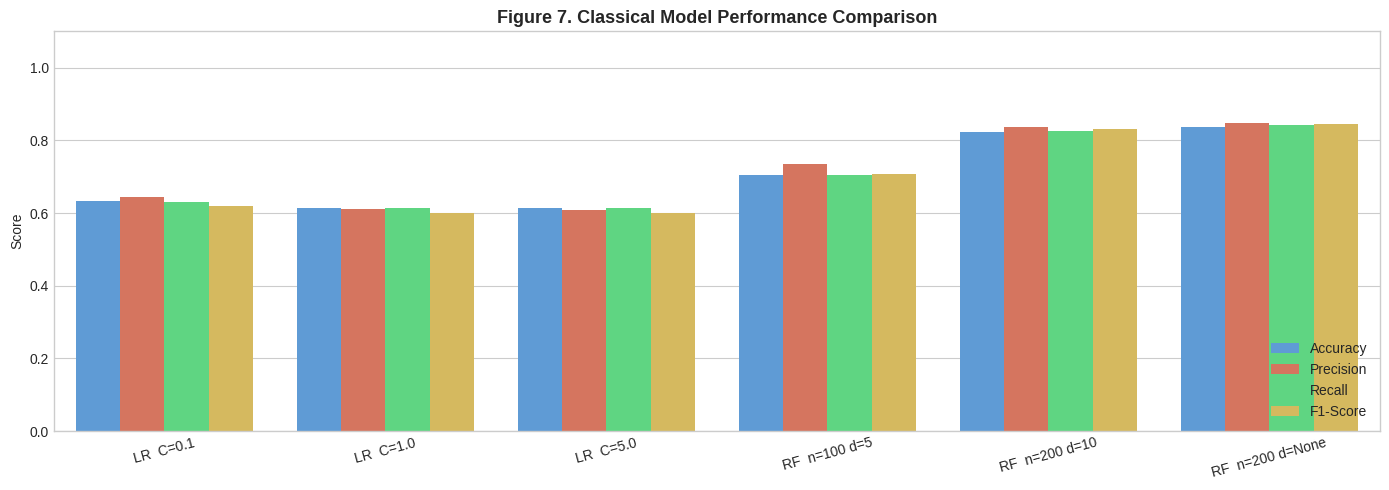


Full classical metrics table:
           Model  Accuracy  Precision   Recall  F1-Score
       LR  C=0.1  0.633987   0.645200 0.630903  0.619308
       LR  C=1.0  0.614379   0.611560 0.614510  0.600744
       LR  C=5.0  0.614379   0.608467 0.614510  0.600701
   RF  n=100 d=5  0.705882   0.735721 0.704367  0.707339
  RF  n=200 d=10  0.823529   0.835631 0.826273  0.830418
RF  n=200 d=None  0.836601   0.848403 0.843082  0.844429


In [ ]:
# Grouped metric bar chart, classical models
metrics_df = pd.DataFrame([{
    'Model':     r['label'],
    'Accuracy':  r['accuracy'],
    'Precision': r['precision'],
    'Recall':    r['recall'],
    'F1-Score':  r['f1']
} for r in results_classical])

melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=melted, x='Model', y='Score', hue='Metric',
            palette=COLORS[:4], ax=ax)
ax.set_ylim(0, 1.1)
ax.set_title('Figure 7. Classical Model Performance Comparison',
             fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print('\nFull classical metrics table:')
print(metrics_df.to_string(index=False))

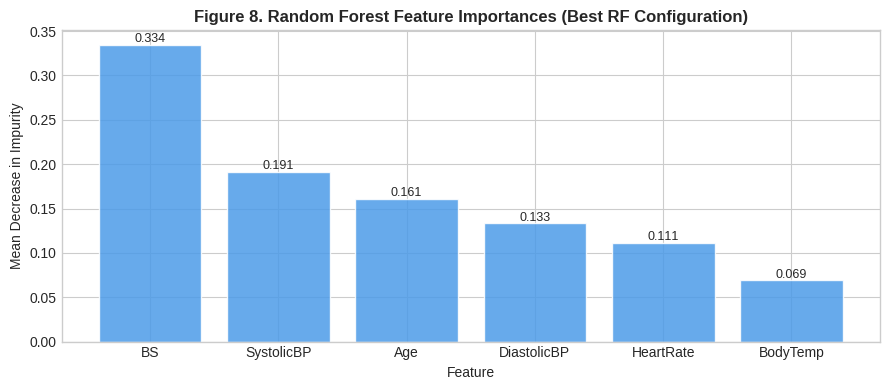

In [ ]:
# Random Forest feature importance cross-referenced with EDA
best_rf = max([r for r in results_classical if 'RF' in r['label']],
              key=lambda r: r['f1'])

importances = best_rf['model'].feature_importances_
sorted_idx  = np.argsort(importances)[::-1]
feat_arr    = np.array(feature_names)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(feat_arr[sorted_idx], importances[sorted_idx],
              color=COLORS[0], alpha=0.85, edgecolor='white')
ax.set_title('Figure 8. Random Forest Feature Importances (Best RF Configuration)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Decrease in Impurity')
ax.set_xlabel('Feature')
for bar, val in zip(bars, importances[sorted_idx]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.003,
            f'{val:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation of Figures 6, 7, and 8.**

Looking at the confusion matrices, I noticed that the mid-risk class was the hardest to predict correctly across all the models, as most of the mistakes happened when mid-risk patients were placed into one of the two adjacent classes, which made sense given how much the classes overlapped in the analysis. Random Forest performed better than Logistic Regression across all the settings I tested, and this was not really a surprise to me because the analysis already showed that the relationship between features like blood glucose and blood pressure was too complex for a simple linear model to handle properly. The feature importance results also matched what I found during the analysis, where blood glucose came out as the most important feature, followed by systolic and diastolic blood pressure, while body temperature and heart rate had the lowest importance scores, which confirmed that my decision to keep all six features was the right one since even the weakest features still contributed some useful information.

## 6.3 ROC-AUC Analysis, Classical Models

To compare the two models more fairly, I also looked at the ROC curves and AUC scores for the best version of each model, using a one-vs-rest approach where each class is compared against the other two. I found this useful because unlike accuracy, the AUC score does not depend on a specific threshold, which gives a better overall picture of how well each model is able to separate the classes from each other.

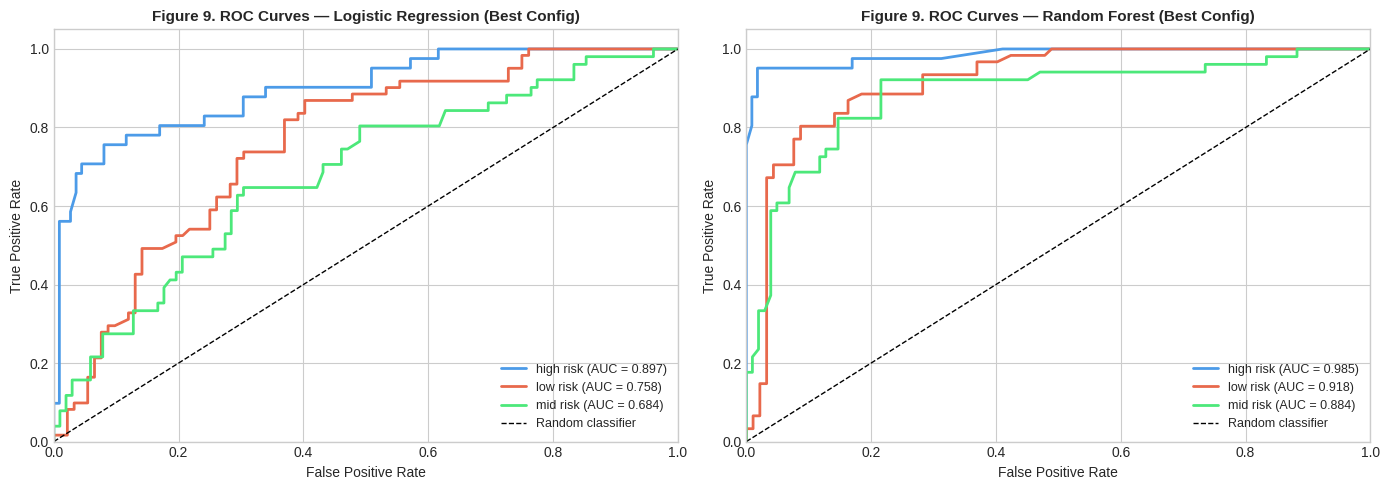

In [ ]:
best_lr     = max([r for r in results_classical if 'LR'  in r['label']],
                  key=lambda r: r['f1'])
best_rf_res = max([r for r in results_classical if 'RF'  in r['label']],
                  key=lambda r: r['f1'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
titles = ['Logistic Regression (Best Config)', 'Random Forest (Best Config)']

for ax, res, title in zip(axes, [best_lr, best_rf_res], titles):
    proba = res.get('proba')
    if proba is None:
        ax.set_title(f'{title}: probabilities unavailable')
        continue
    for class_idx, class_name in enumerate(le.classes_):
        fpr, tpr, _ = roc_curve(y_test_bin[:, class_idx], proba[:, class_idx])
        roc_auc     = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, color=COLORS[class_idx],
                label=f'{class_name} (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
    ax.set_xlim([0, 1]);  ax.set_ylim([0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Figure 9. ROC Curves — {title}', fontsize=11, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

**Interpretation of Figure 9.**

Looking at the ROC curves, both models performed much better than just randomly guessing across all three classes, which was a good sign. The high-risk and low-risk classes had higher AUC scores compared to the mid-risk class, and this was not surprising to me at all because the mid-risk class was always the hardest one to separate from the others, and this goes all the way back to what I noticed during the analysis where the mid-risk patients overlapped quite a bit with the patients in the other two classes.
---
# 7. Neural Network from Scratch

## 7.1 Architecture and Mathematical Derivation

For the neural network, I built a three-layer feed-forward network from scratch using only NumPy, and the design choices I made were based on what I found during the analysis. The input layer had 6 neurons, one for each feature, and the first hidden layer had 64 neurons using ReLU activation, which I chose because it works well for learning complex patterns between features like blood glucose and blood pressure. The second hidden layer had 32 neurons, also with ReLU, and the idea here was to compress the information down and force the network to focus on the most important patterns. The output layer had 3 neurons with softmax activation, which gives a probability for each risk class and makes sure all three probabilities add up to one. For the loss function, I used categorical cross-entropy, which basically measures how far off the predicted probabilities are from the actual labels. I also used He initialisation to set the starting weights, which helps avoid problems with gradients being too small or too large at the beginning of training. Finally, I trained the network using mini-batch gradient descent with a batch size of 32, and the gradients were calculated using backpropagation and the chain rule to update the weights after each batch.

In [ ]:
class NeuralNetworkScratch:
    """
    Three-layer feed-forward neural network implemented in NumPy only.
    Architecture: Input -> Dense(ReLU) -> Dense(ReLU) -> Dense(Softmax).
    Loss:         Categorical Cross-Entropy.
    Optimiser:    Mini-batch Gradient Descent.
    Init:         He initialisation.
    """

    @staticmethod
    def relu(z):
        """ReLU activation: f(z) = max(0, z)."""
        return np.maximum(0, z)

    @staticmethod
    def relu_deriv(z):
        """ReLU subgradient: 1 where z > 0, else 0."""
        return (z > 0).astype(float)

    @staticmethod
    def softmax(z):
        """
        Softmax with row-wise max subtraction for numerical stability.
        f(z_k) = exp(z_k) / sum_j exp(z_j).
        """
        z_stable = z - z.max(axis=1, keepdims=True)
        exp_z = np.exp(z_stable)
        return exp_z / exp_z.sum(axis=1, keepdims=True)

    @staticmethod
    def cross_entropy(y_onehot, y_pred):
        """
        Categorical cross-entropy: L = -1/m * sum(Y * log(Yhat)).
        Epsilon clipping prevents log(0).
        """
        eps = 1e-9
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(np.sum(y_onehot * np.log(y_pred), axis=1))

    @staticmethod
    def one_hot(y, num_classes):
        """Convert integer labels to one-hot matrix."""
        m = len(y)
        oh = np.zeros((m, num_classes))
        oh[np.arange(m), y] = 1.0
        return oh

    def __init__(self, input_dim, hidden1=64, hidden2=32,
                 num_classes=3, lr=0.01, epochs=300, batch_size=32, seed=42):
        self.lr          = lr
        self.epochs      = epochs
        self.batch_size  = batch_size
        self.num_classes = num_classes

        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(0, np.sqrt(2.0 / input_dim),  (input_dim, hidden1))
        self.b1 = np.zeros((1, hidden1))
        self.W2 = rng.normal(0, np.sqrt(2.0 / hidden1),    (hidden1, hidden2))
        self.b2 = np.zeros((1, hidden2))
        self.W3 = rng.normal(0, np.sqrt(2.0 / hidden2),    (hidden2, num_classes))
        self.b3 = np.zeros((1, num_classes))

        self.train_losses = []
        self.val_losses   = []
        self.train_accs   = []
        self.val_accs     = []

    def forward(self, X):
        """
        Forward propagation through all three layers.
        Stores Z and A at each layer for backpropagation.
        Z_l = A_{l-1} W_l + b_l   (affine transformation)
        A_l = activation(Z_l)      (non-linear activation)
        """
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = self.relu(self.Z2)
        self.Z3 = self.A2 @ self.W3 + self.b3
        self.A3 = self.softmax(self.Z3)
        return self.A3

    def backward(self, X, y_onehot):
        """
        Backpropagation via chain rule.

        Output layer (softmax + cross-entropy combined):
          dZ3 = (A3 - Y) / m
          dW3 = A2^T . dZ3
          db3 = mean(dZ3, axis=0)

        Hidden layer 2:
          dA2 = dZ3 . W3^T
          dZ2 = dA2 * relu_prime(Z2)
          dW2 = A1^T . dZ2
          db2 = mean(dZ2, axis=0)

        Hidden layer 1:
          dA1 = dZ2 . W2^T
          dZ1 = dA1 * relu_prime(Z1)
          dW1 = X^T  . dZ1
          db1 = mean(dZ1, axis=0)
        """
        m = X.shape[0]

        dZ3 = (self.A3 - y_onehot) / m
        dW3 = self.A2.T @ dZ3
        db3 = np.mean(dZ3, axis=0, keepdims=True)

        dA2 = dZ3 @ self.W3.T
        dZ2 = dA2 * self.relu_deriv(self.Z2)
        dW2 = self.A1.T @ dZ2
        db2 = np.mean(dZ2, axis=0, keepdims=True)

        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * self.relu_deriv(self.Z1)
        dW1 = X.T @ dZ1
        db1 = np.mean(dZ1, axis=0, keepdims=True)

        # Gradient descent update: W_l <- W_l - alpha * grad
        self.W3 -= self.lr * dW3;  self.b3 -= self.lr * db3
        self.W2 -= self.lr * dW2;  self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1;  self.b1 -= self.lr * db1

    def fit(self, X_tr, y_tr, X_val, y_val):
        """Mini-batch gradient descent training loop."""
        m        = X_tr.shape[0]
        rng      = np.random.default_rng(42)
        y_tr_oh  = self.one_hot(y_tr,  self.num_classes)
        y_val_oh = self.one_hot(y_val, self.num_classes)

        for epoch in range(self.epochs):
            idx  = rng.permutation(m)
            X_sh = X_tr[idx];  y_sh = y_tr_oh[idx]

            for start in range(0, m, self.batch_size):
                Xb = X_sh[start:start + self.batch_size]
                yb = y_sh[start:start + self.batch_size]
                self.forward(Xb)
                self.backward(Xb, yb)

            tr_p  = self.forward(X_tr)
            vl_p  = self.forward(X_val)

            self.train_losses.append(self.cross_entropy(y_tr_oh,  tr_p))
            self.val_losses.append(  self.cross_entropy(y_val_oh, vl_p))
            self.train_accs.append(  np.mean(tr_p.argmax(axis=1) == y_tr))
            self.val_accs.append(    np.mean(vl_p.argmax(axis=1) == y_val))

            if (epoch + 1) % 50 == 0:
                print(f'  Epoch {epoch+1:4d} | '
                      f'Train Loss={self.train_losses[-1]:.4f} '
                      f'Acc={self.train_accs[-1]:.4f} | '
                      f'Val Loss={self.val_losses[-1]:.4f} '
                      f'Acc={self.val_accs[-1]:.4f}')

    def predict(self, X):
        probs = self.forward(X)
        return probs.argmax(axis=1), probs


print('NeuralNetworkScratch class defined successfully.')

NeuralNetworkScratch class defined successfully.


## 7.2 Neural Network Experiments

I ran three experiments to test different training setups for the neural network, changing one thing at a time to see what worked best. In the first experiment, I used a learning rate of 0.01 with the 64 to 32 architecture and trained for 300 epochs, which I used as my starting point since these are pretty standard settings that tend to work well. In the second experiment, I kept the same learning rate and number of epochs but made the network wider by changing the architecture to 128 to 64, and I wanted to see if giving the network more capacity would help it handle the mid-risk class better since that was the hardest one to predict. In the third experiment, I kept the same architecture as the first one but lowered the learning rate to 0.001 and trained for 500 epochs instead, to see if taking smaller and more careful steps during training would help the model find a better solution.

In [ ]:
nn_experiments = [
    dict(label='Exp 1: lr=0.01,  64->32,  300ep',
         hidden1=64,  hidden2=32,  lr=0.01,  epochs=300),
    dict(label='Exp 2: lr=0.01,  128->64, 300ep',
         hidden1=128, hidden2=64,  lr=0.01,  epochs=300),
    dict(label='Exp 3: lr=0.001, 64->32,  500ep',
         hidden1=64,  hidden2=32,  lr=0.001, epochs=500),
]

nn_results  = []
input_dim   = X_train_sc.shape[1]

for cfg in nn_experiments:
    print(f"\n{'='*62}")
    print(f"  Training: {cfg['label']}")
    print('='*62)

    nn = NeuralNetworkScratch(
        input_dim    = input_dim,
        hidden1      = cfg['hidden1'],
        hidden2      = cfg['hidden2'],
        num_classes  = NUM_CLASSES,
        lr           = cfg['lr'],
        epochs       = cfg['epochs'],
        batch_size   = 32,
        seed         = SEED
    )
    nn.fit(X_train_sc, y_train, X_val_sc, y_val)

    y_pred, probs = nn.predict(X_test_sc)
    nn_results.append({
        'label':     cfg['label'],
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall':    recall_score(y_test, y_pred, average='macro', zero_division=0),
        'f1':        f1_score(y_test, y_pred, average='macro', zero_division=0),
        'cm':        confusion_matrix(y_test, y_pred),
        'model':     nn,
        'preds':     y_pred,
        'proba':     probs
    })


  Training: Exp 1: lr=0.01,  64->32,  300ep
  Epoch   50 | Train Loss=0.6328 Acc=0.7278 | Val Loss=0.7522 Acc=0.6513
  Epoch  100 | Train Loss=0.5859 Acc=0.7221 | Val Loss=0.7247 Acc=0.6776
  Epoch  150 | Train Loss=0.5572 Acc=0.7504 | Val Loss=0.7062 Acc=0.6776
  Epoch  200 | Train Loss=0.5327 Acc=0.7687 | Val Loss=0.6880 Acc=0.6842
  Epoch  250 | Train Loss=0.5161 Acc=0.7757 | Val Loss=0.6758 Acc=0.6711
  Epoch  300 | Train Loss=0.4951 Acc=0.7927 | Val Loss=0.6555 Acc=0.6776

  Training: Exp 2: lr=0.01,  128->64, 300ep
  Epoch   50 | Train Loss=0.5860 Acc=0.7419 | Val Loss=0.6978 Acc=0.6513
  Epoch  100 | Train Loss=0.5426 Acc=0.7602 | Val Loss=0.6834 Acc=0.6645
  Epoch  150 | Train Loss=0.5219 Acc=0.7489 | Val Loss=0.6933 Acc=0.6316
  Epoch  200 | Train Loss=0.4908 Acc=0.7828 | Val Loss=0.6664 Acc=0.6579
  Epoch  250 | Train Loss=0.4891 Acc=0.7955 | Val Loss=0.6735 Acc=0.6842
  Epoch  300 | Train Loss=0.4569 Acc=0.7997 | Val Loss=0.6252 Acc=0.7171

  Training: Exp 3: lr=0.001, 64->

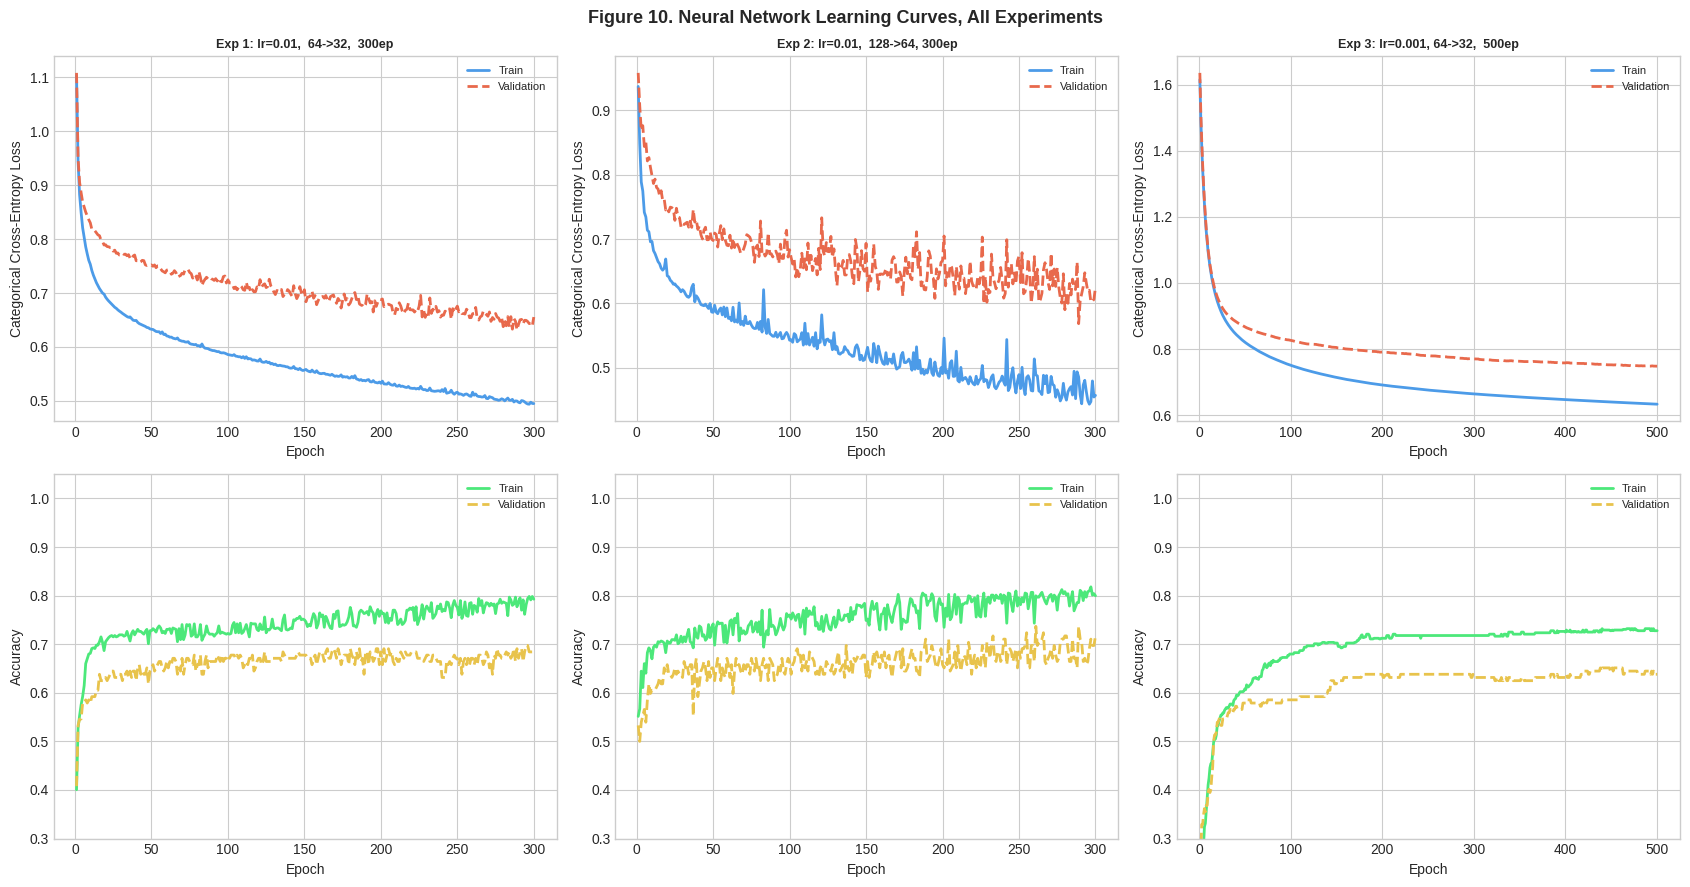


Neural Network Test Set Results:
Exp 1: lr=0.01,  64->32,  300ep            | Acc=0.6993 | P=0.7286 | R=0.7021 | F1=0.7091
Exp 2: lr=0.01,  128->64, 300ep            | Acc=0.7320 | P=0.7678 | R=0.7289 | F1=0.7376
Exp 3: lr=0.001, 64->32,  500ep            | Acc=0.6797 | P=0.7196 | R=0.6745 | F1=0.6810


In [ ]:
# Learning curves, loss and accuracy, all three experiments
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

for i, (res, cfg) in enumerate(zip(nn_results, nn_experiments)):
    nn = res['model']
    ep = np.arange(1, len(nn.train_losses) + 1)

    axes[0, i].plot(ep, nn.train_losses, color=COLORS[0], lw=2, label='Train')
    axes[0, i].plot(ep, nn.val_losses,   color=COLORS[1], lw=2,
                    linestyle='--', label='Validation')
    axes[0, i].set_title(cfg['label'], fontsize=9, fontweight='bold')
    axes[0, i].set_xlabel('Epoch')
    axes[0, i].set_ylabel('Categorical Cross-Entropy Loss')
    axes[0, i].legend(fontsize=8)

    axes[1, i].plot(ep, nn.train_accs, color=COLORS[2], lw=2, label='Train')
    axes[1, i].plot(ep, nn.val_accs,   color=COLORS[3], lw=2,
                    linestyle='--', label='Validation')
    axes[1, i].set_xlabel('Epoch')
    axes[1, i].set_ylabel('Accuracy')
    axes[1, i].set_ylim(0.3, 1.05)
    axes[1, i].legend(fontsize=8)

plt.suptitle('Figure 10. Neural Network Learning Curves, All Experiments',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nNeural Network Test Set Results:')
for r in nn_results:
    print(f"{r['label']:42s} | Acc={r['accuracy']:.4f} | "
          f"P={r['precision']:.4f} | R={r['recall']:.4f} | F1={r['f1']:.4f}")

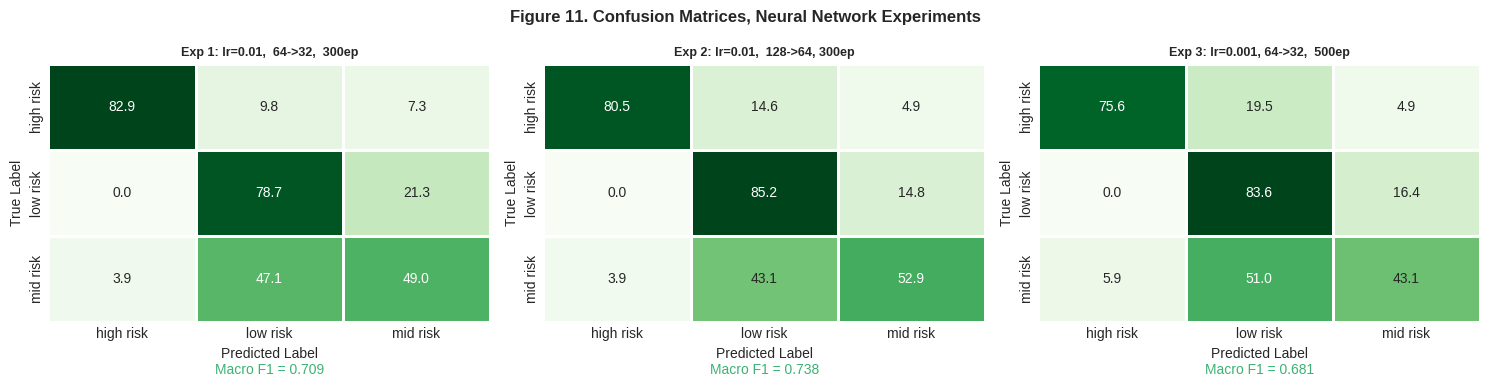

In [ ]:
# Confusion matrices, all three NN experiments
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, res in enumerate(nn_results):
    cm_pct = (res['cm'].astype(float) /
               res['cm'].sum(axis=1, keepdims=True) * 100)
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Greens', ax=axes[i],
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=1, cbar=False)
    axes[i].set_title(res['label'], fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')
    axes[i].text(0.5, -0.2, f'Macro F1 = {res["f1"]:.3f}',
                 ha='center', transform=axes[i].transAxes,
                 fontsize=10, color='#3BB273')

plt.suptitle('Figure 11. Confusion Matrices, Neural Network Experiments',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

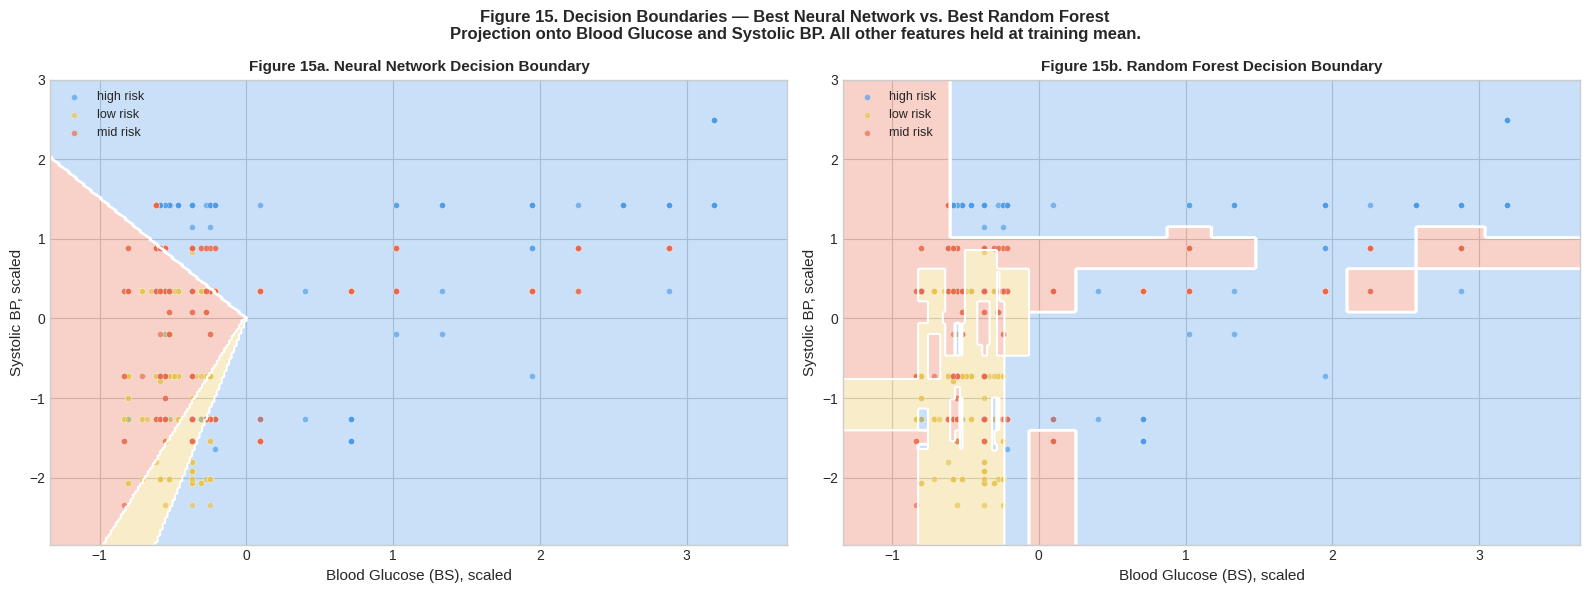

In [ ]:
# Decision boundaries using the two most discriminative features from EDA

best_nn_vis = max(nn_results, key=lambda r: r['f1'])['model']

bs_idx  = feature_names.index('BS')
sbp_idx = feature_names.index('SystolicBP')

bs_range  = np.linspace(X_train_sc[:, bs_idx].min()  - 0.5,
                         X_train_sc[:, bs_idx].max()  + 0.5, 300)
sbp_range = np.linspace(X_train_sc[:, sbp_idx].min() - 0.5,
                         X_train_sc[:, sbp_idx].max() + 0.5, 300)
xx, yy = np.meshgrid(bs_range, sbp_range)

# Full feature grid with non-visualised features at zero
grid_nn = np.zeros((xx.ravel().shape[0], len(feature_names)))
grid_nn[:, bs_idx]  = xx.ravel()
grid_nn[:, sbp_idx] = yy.ravel()

_, grid_probs = best_nn_vis.predict(grid_nn)
zz_nn = grid_probs.argmax(axis=1).reshape(xx.shape)

# Best RF trained on 2 features only for a fair 2D boundary comparison
best_rf_2d = RandomForestClassifier(
    n_estimators=200, max_depth=None,
    random_state=SEED, class_weight='balanced'
)
best_rf_2d.fit(X_train_sc[:, [bs_idx, sbp_idx]], y_train)
grid_2d  = np.column_stack([xx.ravel(), yy.ravel()])
zz_rf    = best_rf_2d.predict(grid_2d).reshape(xx.shape)

class_colors = [COLORS[0], COLORS[3], COLORS[1]]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, zz, title in zip(
    axes,
    [zz_nn, zz_rf],
    ['Figure 15a. Neural Network Decision Boundary',
     'Figure 15b. Random Forest Decision Boundary']
):
    ax.contourf(xx, yy, zz, alpha=0.30,
                colors=class_colors, levels=[-0.5, 0.5, 1.5, 2.5])
    ax.contour(xx, yy, zz, colors='white', linewidths=1.5, levels=[0.5, 1.5])

    for class_idx, class_name in enumerate(le.classes_):
        mask = y_train == class_idx
        ax.scatter(
            X_train_sc[mask, bs_idx],
            X_train_sc[mask, sbp_idx],
            color=class_colors[class_idx],
            label=class_name, s=20, alpha=0.65,
            edgecolors='white', linewidths=0.3
        )
    ax.set_xlabel('Blood Glucose (BS), scaled', fontsize=11)
    ax.set_ylabel('Systolic BP, scaled', fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle(
    'Figure 15. Decision Boundaries — Best Neural Network vs. Best Random Forest\n'
    'Projection onto Blood Glucose and Systolic BP. All other features held at training mean.',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

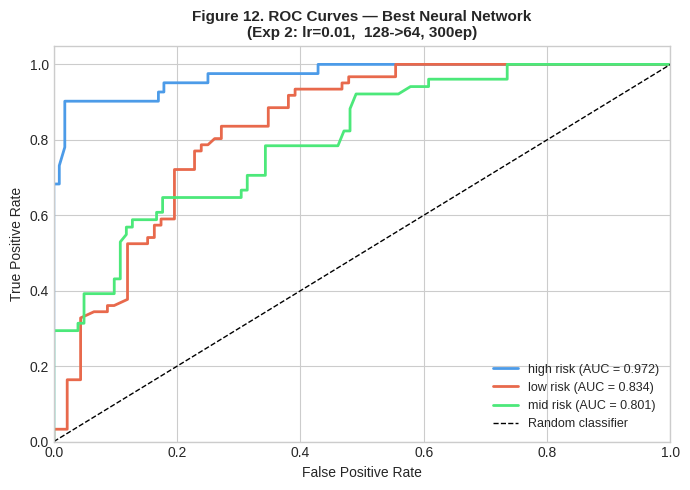

In [ ]:
# ROC curves for best neural network
best_nn_res = max(nn_results, key=lambda r: r['f1'])

fig, ax = plt.subplots(figsize=(7, 5))
for class_idx, class_name in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_test_bin[:, class_idx],
                             best_nn_res['proba'][:, class_idx])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=COLORS[class_idx],
            label=f'{class_name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlim([0, 1]);  ax.set_ylim([0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(
    f'Figure 12. ROC Curves — Best Neural Network\n({best_nn_res["label"]})',
    fontsize=11, fontweight='bold'
)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation of Figures 10, 11, 12, and 15.**

Looking at the training curves, I was happy to see that the loss went down and the accuracy went up across all three experiments, which told me that the network was learning correctly. The first experiment showed that the training and validation curves stayed close to each other, meaning the model was not overfitting. The second experiment had a slightly bigger gap between the two curves later on, which makes sense because a wider network has more parameters and can start to memorise the training data. The third experiment had the smoothest curves out of all three, which showed that the smaller learning rate helped the model learn in a more stable way. The confusion matrices showed the same pattern I already saw with the classical models, where the mid-risk class was still the hardest to get right, and the ROC curves confirmed this too with lower AUC scores for mid-risk, which made me think this difficulty is coming from the data itself and not from the models. Looking at the decision boundaries, Random Forest had a more uneven boundary while the neural network had a smoother one, but both were non-linear, which matched what I expected from the analysis.

---
# 8. Comparative Analysis and Discussion

## 8.1 Final Results Table

In [ ]:
all_results = results_classical + nn_results

comparison_df = pd.DataFrame([{
    'Model':     r['label'],
    'Type':      'Classical' if i < len(results_classical) else 'NN (Scratch)',
    'Accuracy':  round(r['accuracy'], 4),
    'Precision': round(r['precision'], 4),
    'Recall':    round(r['recall'], 4),
    'F1-Score':  round(r['f1'], 4)
} for i, r in enumerate(all_results)])

print('=' * 84)
print('  TABLE 1. Complete Test Set Results — All Models')
print('=' * 84)
print(comparison_df.to_string(index=False))
print('=' * 84)

  TABLE 1. Complete Test Set Results — All Models
                          Model         Type  Accuracy  Precision  Recall  F1-Score
                      LR  C=0.1    Classical    0.6340     0.6452  0.6309    0.6193
                      LR  C=1.0    Classical    0.6144     0.6116  0.6145    0.6007
                      LR  C=5.0    Classical    0.6144     0.6085  0.6145    0.6007
                  RF  n=100 d=5    Classical    0.7059     0.7357  0.7044    0.7073
                 RF  n=200 d=10    Classical    0.8235     0.8356  0.8263    0.8304
               RF  n=200 d=None    Classical    0.8366     0.8484  0.8431    0.8444
Exp 1: lr=0.01,  64->32,  300ep NN (Scratch)    0.6993     0.7286  0.7021    0.7091
Exp 2: lr=0.01,  128->64, 300ep NN (Scratch)    0.7320     0.7678  0.7289    0.7376
Exp 3: lr=0.001, 64->32,  500ep NN (Scratch)    0.6797     0.7196  0.6745    0.6810


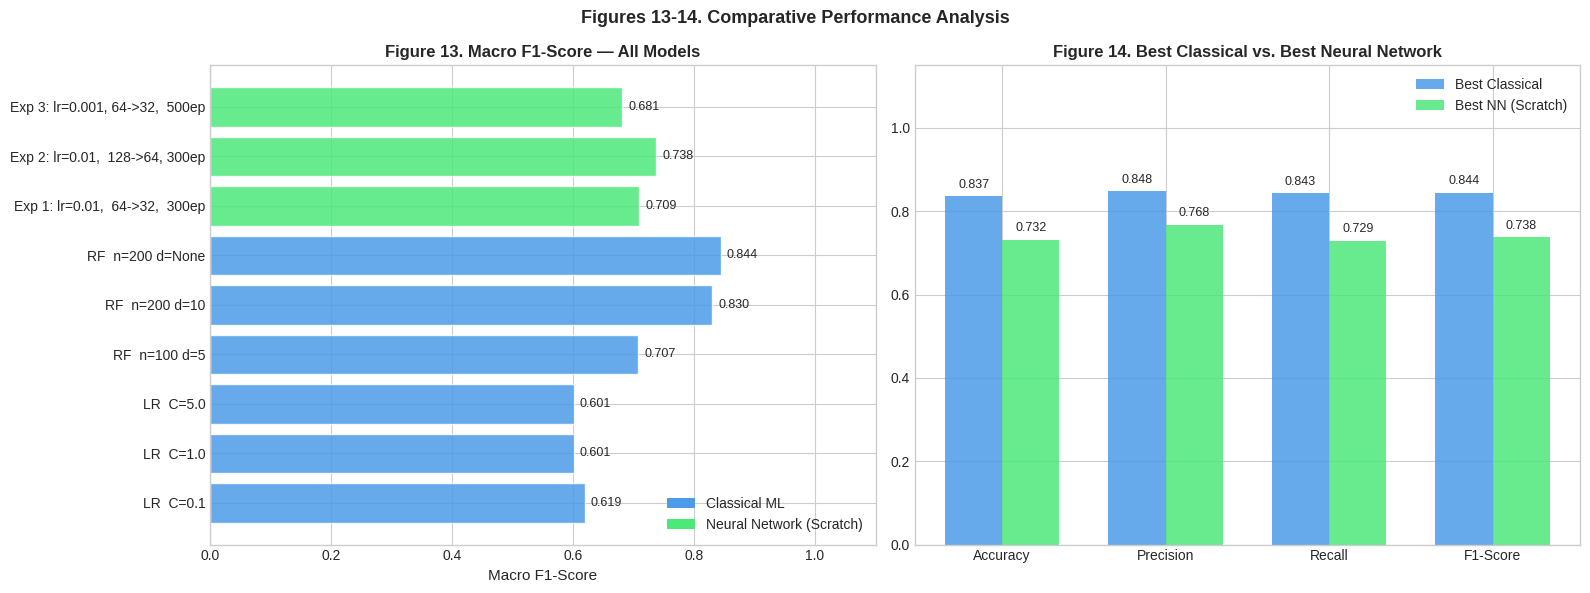

In [ ]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors_bar = ([COLORS[0]] * len(results_classical) +
              [COLORS[2]] * len(nn_results))
labels = [r['label'] for r in all_results]
f1s    = [r['f1']    for r in all_results]

bars = axes[0].barh(labels, f1s, color=colors_bar, alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Macro F1-Score', fontsize=11)
axes[0].set_title('Figure 13. Macro F1-Score — All Models',
                  fontsize=12, fontweight='bold')
axes[0].set_xlim(0, 1.1)
for bar, val in zip(bars, f1s):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', fontsize=9)
axes[0].legend(handles=[
    Patch(facecolor=COLORS[0], label='Classical ML'),
    Patch(facecolor=COLORS[2], label='Neural Network (Scratch)')
], loc='lower right')

best_cls = max(results_classical, key=lambda r: r['f1'])
best_nn  = max(nn_results,        key=lambda r: r['f1'])

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
vals_cls = [best_cls['accuracy'], best_cls['precision'],
            best_cls['recall'],   best_cls['f1']]
vals_nn  = [best_nn['accuracy'],  best_nn['precision'],
            best_nn['recall'],    best_nn['f1']]

x = np.arange(len(metric_names))
w = 0.35
axes[1].bar(x - w/2, vals_cls, w, label='Best Classical',     color=COLORS[0], alpha=0.85)
axes[1].bar(x + w/2, vals_nn,  w, label='Best NN (Scratch)',  color=COLORS[2], alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(metric_names)
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Figure 14. Best Classical vs. Best Neural Network',
                  fontsize=12, fontweight='bold')
axes[1].legend()
for xi, (vc, vn) in enumerate(zip(vals_cls, vals_nn)):
    axes[1].text(xi - w/2, vc + 0.02, f'{vc:.3f}', ha='center', fontsize=9)
    axes[1].text(xi + w/2, vn + 0.02, f'{vn:.3f}', ha='center', fontsize=9)

plt.suptitle('Figures 13-14. Comparative Performance Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8.2 Discussion

### What Each Method Does Well and Where It Struggles

**Logistic Regression** was the simplest model I tested, and it worked reasonably well for the high-risk and low-risk classes because those two classes had a fairly clear and straightforward relationship with features like blood glucose and blood pressure. However, it struggled with the mid-risk class because logistic regression draws a straight decision boundary, and the mid-risk patients overlapped too much with the other two classes for a straight line to separate them properly. This is a known limitation of linear models when the data has complex, non-linear patterns.

**Random Forest** was the best performing model overall, and this was not surprising to me because it is specifically designed to handle complex and non-linear relationships between features. Unlike logistic regression, Random Forest builds many decision trees and combines their results, which allows it to capture interactions between features, such as how high blood glucose combined with high blood pressure together signal a higher risk level in a way that neither feature alone can fully explain. Another reason Random Forest performed well on this dataset is that it works very effectively on small tabular datasets like this one, where there are only 1,013 rows and six features, because it does not need a large amount of data to generalise well.

**The neural network**, which I built entirely from scratch, also learned non-linear boundaries and performed better than logistic regression, but it did not manage to beat Random Forest. I think the main reason for this is the size of the dataset. Neural networks generally need a large amount of data to reach their full potential because they have many more parameters to learn compared to Random Forest, and with only around 700 training samples, the network did not have enough data to learn the patterns as effectively. If the dataset were much larger, the neural network might have performed differently. All three models consistently struggled with the mid-risk class, and I believe this is an intrinsic property of the data itself rather than a weakness of any particular model, because the mid-risk patients genuinely share similar medical measurements with both low-risk and high-risk patients, making them inherently harder to classify correctly.

---
# 9. References

* Ahmed, M., Kashem, M. A., Rahman, M., & Khatun, S. (2020). Maternal Health Risk [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5DP5D
* Breiman, L. (2001). Random forests. Machine Learning, 45(1), 5–32. https://doi.org/10.1023/A:1010933404324
* Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep learning. MIT Press.
* World Health Organization. (2024). Maternal mortality [Fact sheet]. https://www.who.int/news-room/fact-sheets/detail/maternal-mortality

Note: I used Grammarly to check and correct the writing throughout this assignment.
